<a href="https://colab.research.google.com/github/Thaer-F-Ali/Logistitc_Regression_Implimitation/blob/main/logistic_regression_implimintaion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  1st Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for binary classification tasks. Below is a Python implementation using the scikit-learn library.

Steps to Implement Logistic Regression

1. Import Required Libraries

In [23]:
# 1. Laoding libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from matplotlib.patches import ConnectionPatch
from scipy.stats import norm
import statistics
import plotly.graph_objects as go
import plotly.express as px
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)


2. Load and Prepare the Dataset

For demonstration, we'll use the diabetes dataset from sklearn.

In [8]:
# 2. Loading dataset and prepare dataset
from sklearn.datasets import load_diabetes
# Load dataset
data = load_diabetes()
X, y = data.data, data.target
# Convert target to binary (1 for diabetes, 0 for no diabetes)
y_binary = (y > np.median(y)).astype(int)

3. Split the Dataset

Split the data into training and testing sets.

In [9]:
# 3. Spliting data
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.3, random_state=42)

4. Feature Scaling

Standardize features to improve model performance.

In [10]:
# 4. Scalling data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

5. Train the Logistic Regression Model

Fit the logistic regression model on the training data.

In [11]:
# 5. Create logistic model and train it
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

6. Evaluate the Model

Evaluate the model's performance using accuracy and other metrics.

In [12]:
#6  Predict on test data
y_pred = model.predict(X_test)

# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix and Classification Report
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 77.44%
Confusion Matrix:
 [[56 16]
 [14 47]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.78      0.79        72
           1       0.75      0.77      0.76        61

    accuracy                           0.77       133
   macro avg       0.77      0.77      0.77       133
weighted avg       0.78      0.77      0.77       133



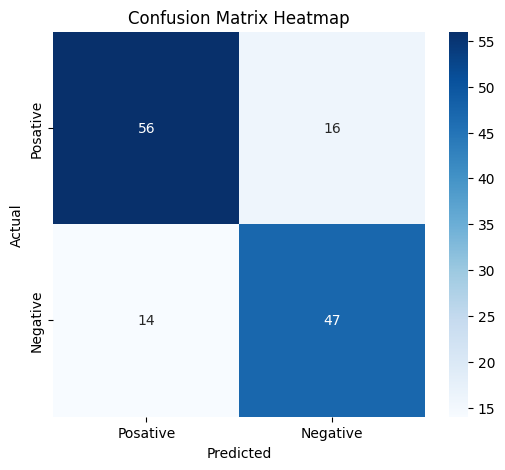

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Posative', 'Negative'], yticklabels=['Posative', 'Negative'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [13]:
# 7. printing the resuls (this source for comparing the results with program in the Applied Machine Learning with Python book, page 62)

print('Prediction:', y_pred[1], y_pred[9], y_pred[25])
print('Raw Model Output X_test: ',
      (model.coef_@ X_test[1]+model.intercept_),
      (model.coef_@X_test[9]+model.intercept_),
      (model.coef_@X_test[25] + model.intercept_))


Prediction: 1 0 1
Raw Model Output X_test:  [1.47532634] [-1.67518769] [0.52654523]


# 2nd Logistic Regersion

This model is from the Applied Machine Learning with Python book-page 62

In [15]:
# 1. Preparing data
X = data.data
y = data.target
print(data.feature_names)
print(data.DESCR)


['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, bloo

In [16]:
# 2. Spliting data
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size= 0.3, random_state= 42)

In [17]:
# 3. Craeting the model and train it
lr = LogisticRegression()
lr.fit(X_train, y_train)


LogisticRegression()

In [18]:
# 3. Testting and evaluating the model
y_pred = lr.predict(X_test)

In [19]:
# 4. Examining the results
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix and Classification Report
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 80.45%
Confusion Matrix:
 [[56 16]
 [10 51]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.78      0.81        72
           1       0.76      0.84      0.80        61

    accuracy                           0.80       133
   macro avg       0.80      0.81      0.80       133
weighted avg       0.81      0.80      0.80       133



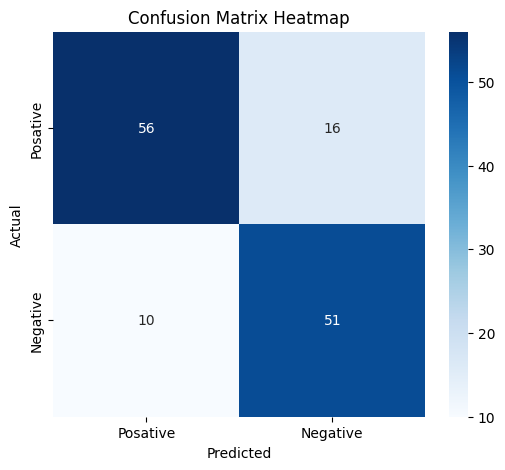

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Posative', 'Negative'], yticklabels=['Posative', 'Negative'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

### Comparing Coefficients of Scaled vs. Unscaled Models

In [21]:
# 5. Printing the coefficients
print('Prediction:', lr.predict(X_test)[1], lr.predict(X_test)[9], lr.predict(X_test)[25])
print('Raw Model Output X_test: ',
      (lr.coef_@ X_test[1] + lr.intercept_),
      (lr.coef_@ X_test[9] + lr.intercept_),
      (lr.coef_@ X_test[25]+ lr.intercept_))


Prediction: 1 0 1
Raw Model Output X_test:  [0.1352537] [-0.09852356] [0.17023003]


In [22]:
# 6. Comparing cofficients of the scaled and unscaled models
print("Scaled Model (model):")
print("  Coefficients:", model.coef_)
print("  Intercept:", model.intercept_)

print("\nUnscaled Model (lr):")
print("  Coefficients:", lr.coef_)
print("  Intercept:", lr.intercept_)

Scaled Model (model):
  Coefficients: [[ 0.10500243 -0.58724547  0.67459032  0.61835658 -0.32022822 -0.08939562
  -0.52441695  0.09787805  0.62173009 -0.04851767]]
  Intercept: [0.14722282]

Unscaled Model (lr):
  Coefficients: [[ 0.57359398 -0.65002523  2.35591272  1.85001384  0.18766705  0.06003926
  -1.59215119  1.32216707  1.94320318  1.15471231]]
  Intercept: [0.05378309]


# 3rd Logistic Regression with data analysis in real example

*   This example is from the Kegale platform with name Diabetes Analysis
*   The dataset is a collection from  African-American patients were included


---





In [24]:
# 1. Importing dataset
# Please upload 'diabetes.csv' to your Colab session, or provide the correct path.
diab_data3= pd.read_csv('/content/sample_data/germany_diabetes.csv')
diab_data3.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,0
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,0
3,0,135,68,42,250,42.3,0.365,24,0
4,1,139,62,41,480,40.7,0.536,21,0


In [25]:
# Rename the boood_glucose_level to glyhd
diab_data3 = diab_data3.rename(columns={'Outcome': 'glyhb'})
diab_data3.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,glyhb
0,2,138,62,35,0,33.6,0.127,47,0
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,0
3,0,135,68,42,250,42.3,0.365,24,0
4,1,139,62,41,480,40.7,0.536,21,0


In [26]:
# Exploring data in the dataset
diab_data3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   int64  
 1   Glucose                   2000 non-null   int64  
 2   BloodPressure             2000 non-null   int64  
 3   SkinThickness             2000 non-null   int64  
 4   Insulin                   2000 non-null   int64  
 5   BMI                       2000 non-null   float64
 6   DiabetesPedigreeFunction  2000 non-null   float64
 7   Age                       2000 non-null   int64  
 8   glyhb                     2000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.8 KB


### Building LR model

Descriptive statistics for 'diabetes' column:


,DiabetesPedigreeFunction
count,2000.000000
mean,0.470930
std,0.323553
min,0.078000
25%,0.244000
50%,0.376000
75%,0.624000
max,2.420000


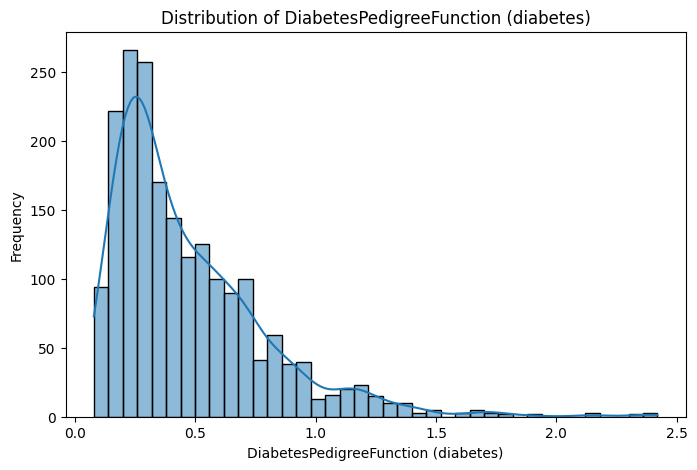

In [27]:
# 2.Understanding the 'DiabetesPedigreeFunction' column
# Display descriptive statistics for 'diabetes'
print("Descriptive statistics for 'diabetes' column:")
display(diab_data3['DiabetesPedigreeFunction'].describe())

# Visualize the distribution of 'glyhd'
plt.figure(figsize=(8, 5))
sns.histplot(diab_data3['DiabetesPedigreeFunction'], kde=True)
plt.title('Distribution of DiabetesPedigreeFunction (diabetes)')
plt.xlabel('DiabetesPedigreeFunction (diabetes)')
plt.ylabel('Frequency')
plt.show()

In [47]:
diab_data3

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,glyhb
0,2,138,62,35,0,33.6,0.127,47,0
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,0
3,0,135,68,42,250,42.3,0.365,24,0
4,1,139,62,41,480,40.7,0.536,21,0
...,...,...,...,...,...,...,...,...,...
1995,2,75,64,24,55,29.7,0.370,33,1
1996,8,179,72,42,130,32.7,0.719,36,1
1997,6,85,78,0,0,31.2,0.382,42,1
1998,0,129,110,46,130,67.1,0.319,26,1


In [48]:
# 3 Exploring nan in the data
print(diab_data3.info())
diab_data3.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   int64  
 1   Glucose                   2000 non-null   int64  
 2   BloodPressure             2000 non-null   int64  
 3   SkinThickness             2000 non-null   int64  
 4   Insulin                   2000 non-null   int64  
 5   BMI                       2000 non-null   float64
 6   DiabetesPedigreeFunction  2000 non-null   float64
 7   Age                       2000 non-null   int64  
 8   glyhb                     2000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.8 KB
None


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
glyhb,0


In [49]:
# 4 Cleaning data
# Droping rows where 'glyhb' has missing values
diab_data = diab_data3.dropna(subset=['glyhb'], how='any')

In [50]:
# 5. Cheking nan in the data
print(diab_data3.info())
diab_data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   int64  
 1   Glucose                   2000 non-null   int64  
 2   BloodPressure             2000 non-null   int64  
 3   SkinThickness             2000 non-null   int64  
 4   Insulin                   2000 non-null   int64  
 5   BMI                       2000 non-null   float64
 6   DiabetesPedigreeFunction  2000 non-null   float64
 7   Age                       2000 non-null   int64  
 8   glyhb                     2000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.8 KB
None


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
glyhb,0


In [51]:
# 6. Converting string data to number (Location, Gender, and Fram) for finding the correlattion between them
'''gender_map = {
    'Female': 0,
    'Male': 1
}
diab_data['gender'] = diab_data['gender'].map(gender_map)'''

'''location_map = {
    'Urban': 0,
    'Rural': 1
}
diab_data['location'] = diab_data['location'].map(location_map)

fram_map = {
    'No': 0,
    'Yes': 1
}
diab_data['frame'] = diab_data['frame'].map(fram_map)'''

"location_map = {\n    'Urban': 0,\n    'Rural': 1\n}\ndiab_data['location'] = diab_data['location'].map(location_map)\n\nfram_map = {\n    'No': 0,\n    'Yes': 1\n}\ndiab_data['frame'] = diab_data['frame'].map(fram_map)"

In [52]:
# Deleting geneder column
#diab_data = diab_data.drop('gender', axis=1)
#diab_data = diab_data.drop(columns=['smoking_history'])


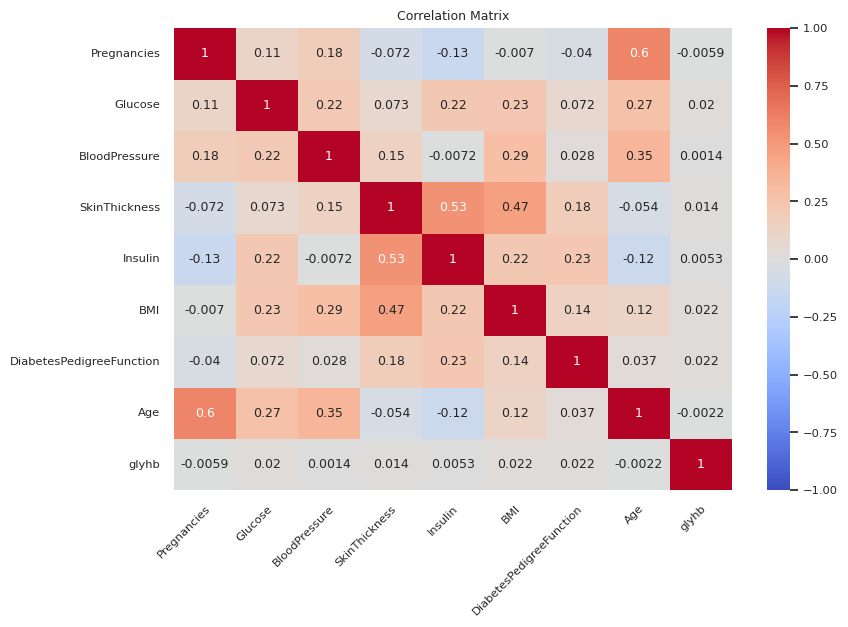

In [53]:
# 7. Showing the unnacessory columns ('smoking_history') to show clear corelationship

corr = diab_data3.corr('spearman')
plt.figure(figsize=(9,6))
sns.set(font_scale=0.75)
ax = sns.heatmap(corr, vmin=-1, center=0, vmax=1, annot=True, cmap='coolwarm')
# Rotate x-axis labels (column names)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
# Rotate y-axis labels (column names)
plt.setp(ax.get_yticklabels(), rotation=0)
plt.title('Correlation Matrix')
plt.show()

In [54]:
# 8.1 Deleting unusfel columns that show low correlation with glyb label
'''diab_data3_corr = diab_data3.drop(['id','location', 'gender','frame'], axis =1).corr('spearman')
for col in diab_data3_corr.columns:
   if (diab_data3_corr['glyhb'].corr(diab_data3_corr[col])<=0):
    diab_data3_corr = diab_data3_corr.drop(col, axis=1)'''

"diab_data3_corr = diab_data3.drop(['id','location', 'gender','frame'], axis =1).corr('spearman')\nfor col in diab_data3_corr.columns:\n   if (diab_data3_corr['glyhb'].corr(diab_data3_corr[col])<=0):\n    diab_data3_corr = diab_data3_corr.drop(col, axis=1)"

In [55]:
# 8.2 This step is another way to drop columns
# Dropping uncorelated columns to the glyhb column
diab_data3_corr = diab_data3.copy() # Make a copy to avoid modifying the original DataFrame
x = 0
for col in diab_data3_corr.columns:
   if col == 'glyhb': # Skip the target column itself
       print(f"Skipping target column: '{col}'")
       continue

   # Calculate correlation, handling potential NaN values if a column is all NaNs after dropna()
   if diab_data3_corr[col].isnull().all(): # Check if column is entirely NaN
       correlation = 0 # Or handle as appropriate, e.g., drop it always
   else:
       correlation = diab_data3_corr['glyhb'].corr(diab_data3_corr[col])

   if (correlation <= 0.0):
    diab_data3_corr = diab_data3_corr.drop(col, axis=1)
    x = x+1
    print(f"True: Column '{col}' dropped due to correlation <= 0 (Correlation: {correlation:.2f})")
   else:
    print(f"False: Column '{col}' kept (Correlation: {correlation:.2f})")
print(f"Total columns dropped: {x}")


True: Column 'Pregnancies' dropped due to correlation <= 0 (Correlation: -0.01)
False: Column 'Glucose' kept (Correlation: 0.02)
True: Column 'BloodPressure' dropped due to correlation <= 0 (Correlation: -0.00)
False: Column 'SkinThickness' kept (Correlation: 0.02)
False: Column 'Insulin' kept (Correlation: 0.02)
False: Column 'BMI' kept (Correlation: 0.03)
False: Column 'DiabetesPedigreeFunction' kept (Correlation: 0.01)
True: Column 'Age' dropped due to correlation <= 0 (Correlation: -0.01)
Skipping target column: 'glyhb'
Total columns dropped: 3


In [56]:
# 8.3 Dropping all zero values from columns except glyhb
'''x = 0
for col in diab_data3.columns:
   if col == 'glyhb': # Skip the target column itself
       print(f"Skipping target column: '{col}'")
       continue
       # Validate column existence
   if col in diab_data3.columns:
        # Keep only rows where the column is NOT zero
        diab_data3 = diab_data3[diab_data3[col] != 0].reset_index(drop=True)
   else:
        raise ValueError(f"Column '{col}' does not exist in DataFrame.")'''

'x = 0\nfor col in diab_data3.columns:\n   if col == \'glyhb\': # Skip the target column itself\n       print(f"Skipping target column: \'{col}\'")\n       continue\n       # Validate column existence\n   if col in diab_data3.columns:\n        # Keep only rows where the column is NOT zero\n        diab_data3 = diab_data3[diab_data3[col] != 0].reset_index(drop=True)\n   else:\n        raise ValueError(f"Column \'{col}\' does not exist in DataFrame.")'

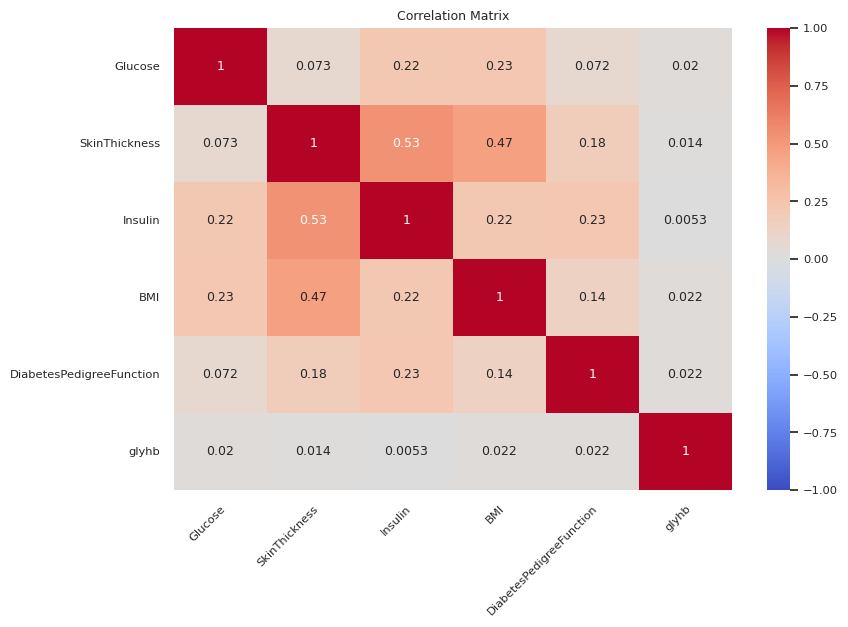

In [57]:
# 9. Exploring the correlation map with glyb for double check
corr = diab_data3_corr.corr('spearman')
plt.figure(figsize=(9,6))
sns.set(font_scale=0.75)
ax = sns.heatmap(corr, vmin=-1, center=0, vmax=1, annot=True, cmap='coolwarm')
# Rotate x-axis labels (column names)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
# Rotate y-axis labels (column names)
plt.setp(ax.get_yticklabels(), rotation=0)
plt.title('Correlation Matrix')
plt.show()

In [58]:
# 10. Building data for the model

# First, ensure consistency by dropping rows with any NaN values from the relevant columns
# This step ensures X and y will have the same number of samples.
diab_data3_cleaned = diab_data3.dropna(how='any')

X = diab_data3_cleaned.drop('glyhb', axis=1)
y = diab_data3_cleaned['glyhb']

# Convert target to binary (1 for diabetes, 0 for no diabetes)
# Using a common clinical threshold for HbA1c: >= 6.5% for diabetes
#y_binary = (y >= 6.5).astype(int)
y_binary = (y > np.median(y)).astype(int)

# Spliting data
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size= 0.3, random_state= 42)

# Normalizing data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

count    2000.000000
mean        0.342000
std         0.474498
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: glyhb, dtype: float64


<Axes: xlabel='glyhb', ylabel='Count'>

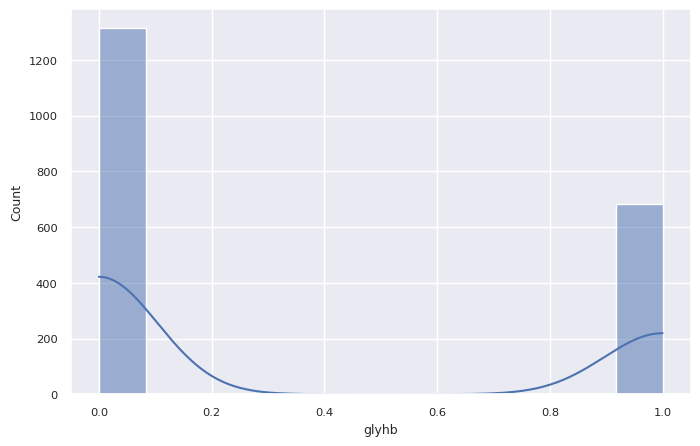

In [59]:
# 11. Exploring the glyhb column
glyb = diab_data3_corr['glyhb']
print(glyb.describe())
plt.figure(figsize=(8, 5))
sns.histplot(glyb.dropna(), kde=True)

In [60]:
# 12. Building the Logistic Regression model
model3 = LogisticRegression()
model3.fit(X_train, y_train)

LogisticRegression()

In [61]:
# 13. Predict on test data
y_pred = model3.predict(X_test)

# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix and Classification Report
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 63.83%
Confusion Matrix:
 [[383   0]
 [217   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.64      1.00      0.78       383
           1       0.00      0.00      0.00       217

    accuracy                           0.64       600
   macro avg       0.32      0.50      0.39       600
weighted avg       0.41      0.64      0.50       600



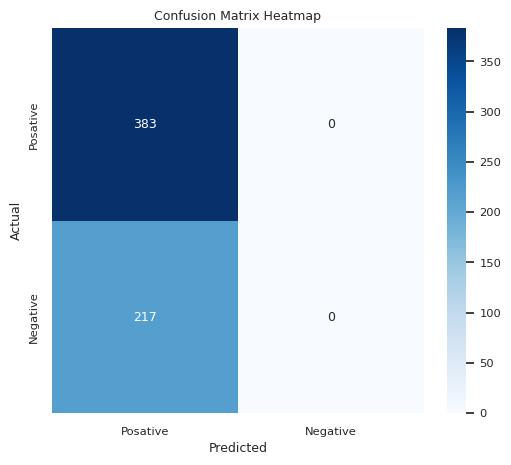

In [62]:
# 14  Plot confusion matrix as heatmap
import seaborn as sns


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Posative', 'Negative'], yticklabels=['Posative', 'Negative'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [63]:
# 15. Printing the resuls (this source for comparing the results with program in the Applied Machine Learning with Python book, page 62)

print('Prediction:', y_pred[1], y_pred[30], y_pred[75])
print('Raw Model Output X_test: ',
      (model3.coef_@ X_test[1]+model3.intercept_),
      (model3.coef_@X_test[10]+model3.intercept_),
      (model3.coef_@X_test[75] + model3.intercept_))

Prediction: 0 0 0
Raw Model Output X_test:  [-0.66727492] [-0.68103488] [-0.65787607]


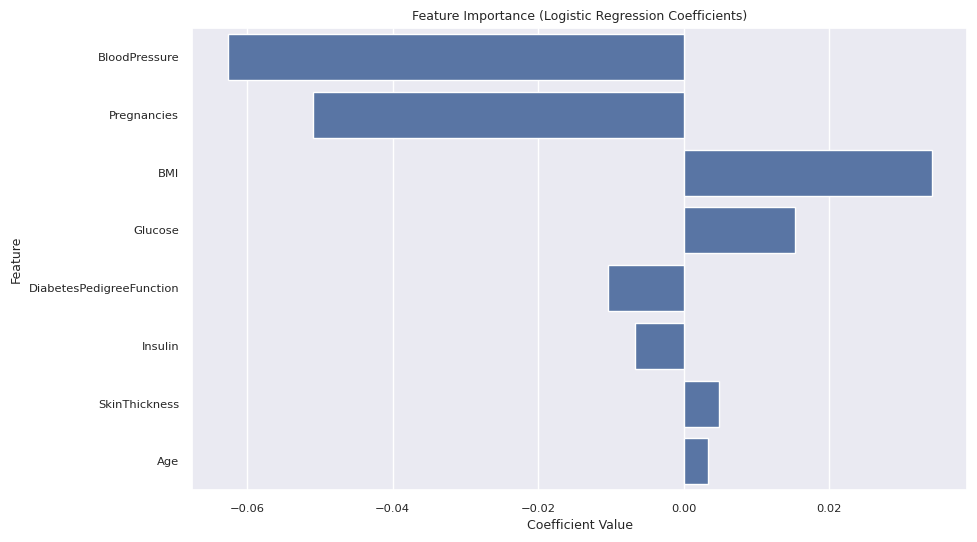

In [64]:
# 16. Coefficients for each feature
feature_importance = pd.DataFrame({'feature': X.columns, 'coefficient': model3.coef_[0]})
feature_importance['abs_coefficient'] = abs(feature_importance['coefficient'])
feature_importance = feature_importance.sort_values(by='abs_coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='coefficient', y='feature', data=feature_importance)
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

AUC Score: 0.4781


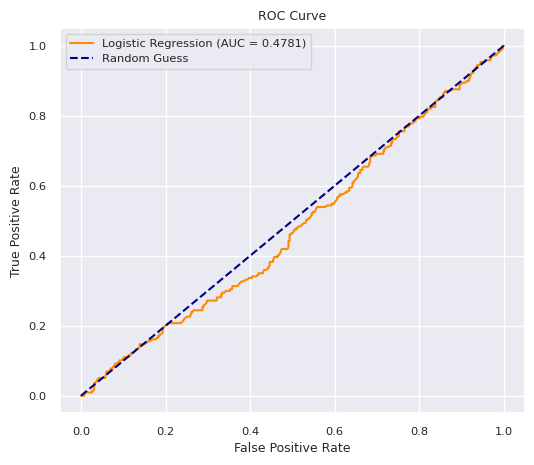

In [65]:
# 17 Plorint area under curve
#Predict probabilities for the positive class
y_probs = model3.predict_proba(X_test)[:, 1]

    # Calculate AUC
from sklearn.metrics import roc_auc_score, roc_curve
auc_score = roc_auc_score(y_test, y_probs)
print(f"AUC Score: {auc_score:.4f}")

# Optional: Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.4f})', color='darkorange',  )
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess', color='navy')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

In [66]:
len(y_test)

600

# 4th Logistic Regression

##    Building LR model

In [67]:
# 1. Importing dataset
# Please upload 'diabetes.csv' to your Colab session, or provide the correct path.
diab_data4= pd.read_csv('/content/sample_data/Db.csv')
diab_data4.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Descriptive statistics for 'diabetes' column:


,DiabetesPedigreeFunction
count,768.000000
mean,0.471876
std,0.331329
min,0.078000
25%,0.243750
50%,0.372500
75%,0.626250
max,2.420000


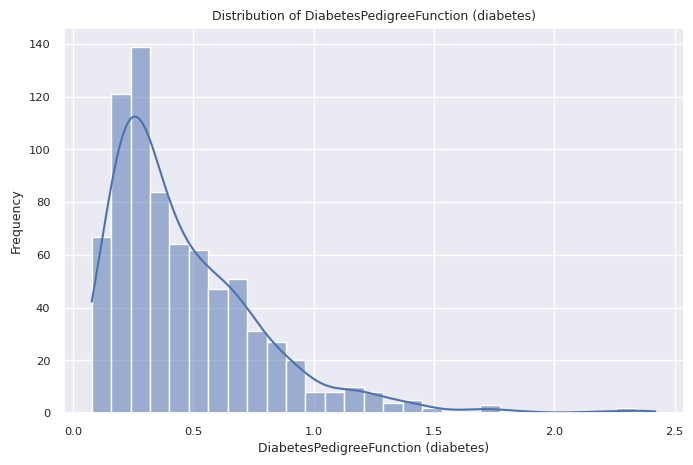

In [68]:
# 2.Understanding the 'diabetes' column
# Display descriptive statistics for 'diabetes'
print("Descriptive statistics for 'diabetes' column:")
display(diab_data4['DiabetesPedigreeFunction'].describe())

# Visualize the distribution of 'glyhd'
plt.figure(figsize=(8, 5))
sns.histplot(diab_data4['DiabetesPedigreeFunction'], kde=True)
plt.title('Distribution of DiabetesPedigreeFunction (diabetes)')
plt.xlabel('DiabetesPedigreeFunction (diabetes)')
plt.ylabel('Frequency')
plt.show()

In [69]:
# 3 Exploring nan in the data
print(diab_data4.info())
diab_data4.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [70]:
# Rename the boood_glucose_level to glyhd
diab_data4 = diab_data4.rename(columns={'Outcome': 'glyhb'})
diab_data4.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,glyhb
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [71]:
# 4 Cleaning data
# Droping rows where 'glyhb' has missing values
diab_data4 = diab_data4.dropna(subset=['glyhb'], how='any')

In [72]:
# 5. Cheking nan in the data
print(diab_data4.info())
diab_data4.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   glyhb                     768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
glyhb,0


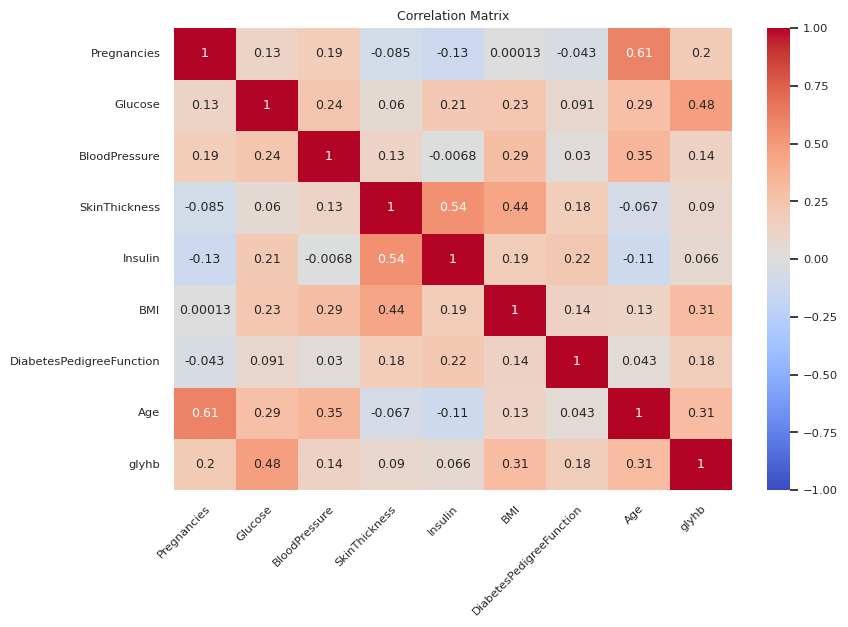

In [73]:
# 7. Showing the unnacessory columns ('smoking_history') to show clear corelationship

corr = diab_data4.corr('spearman')
plt.figure(figsize=(9,6))
sns.set(font_scale=0.75)
ax = sns.heatmap(corr, vmin=-1, center=0, vmax=1, annot=True, cmap='coolwarm')
# Rotate x-axis labels (column names)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
# Rotate y-axis labels (column names)
plt.setp(ax.get_yticklabels(), rotation=0)
plt.title('Correlation Matrix')
plt.show()

In [74]:
# 8. This step is another way to drop columns
# Dropping uncorelated columns to the glyhb column
diab_data4_corr = diab_data4.copy() # Make a copy to avoid modifying the original DataFrame
x = 0
for col in diab_data4_corr.columns:
   if col == 'glyhb': # Skip the target column itself
       print(f"Skipping target column: '{col}'")
       continue

   # Calculate correlation, handling potential NaN values if a column is all NaNs after dropna()
   if diab_data4_corr[col].isnull().all(): # Check if column is entirely NaN
       correlation = 0 # Or handle as appropriate, e.g., drop it always
   else:
       correlation = diab_data4_corr['glyhb'].corr(diab_data4_corr[col])

   if (correlation <= 0.0):
    diab_data4_corr = diab_data4_corr.drop(col, axis=1)
    x = x+1
    print(f"True: Column '{col}' dropped due to correlation <= 0 (Correlation: {correlation:.2f})")
   else:
    print(f"False: Column '{col}' kept (Correlation: {correlation:.2f})")
print(f"Total columns dropped: {x}")

False: Column 'Pregnancies' kept (Correlation: 0.22)
False: Column 'Glucose' kept (Correlation: 0.47)
False: Column 'BloodPressure' kept (Correlation: 0.07)
False: Column 'SkinThickness' kept (Correlation: 0.07)
False: Column 'Insulin' kept (Correlation: 0.13)
False: Column 'BMI' kept (Correlation: 0.29)
False: Column 'DiabetesPedigreeFunction' kept (Correlation: 0.17)
False: Column 'Age' kept (Correlation: 0.24)
Skipping target column: 'glyhb'
Total columns dropped: 0


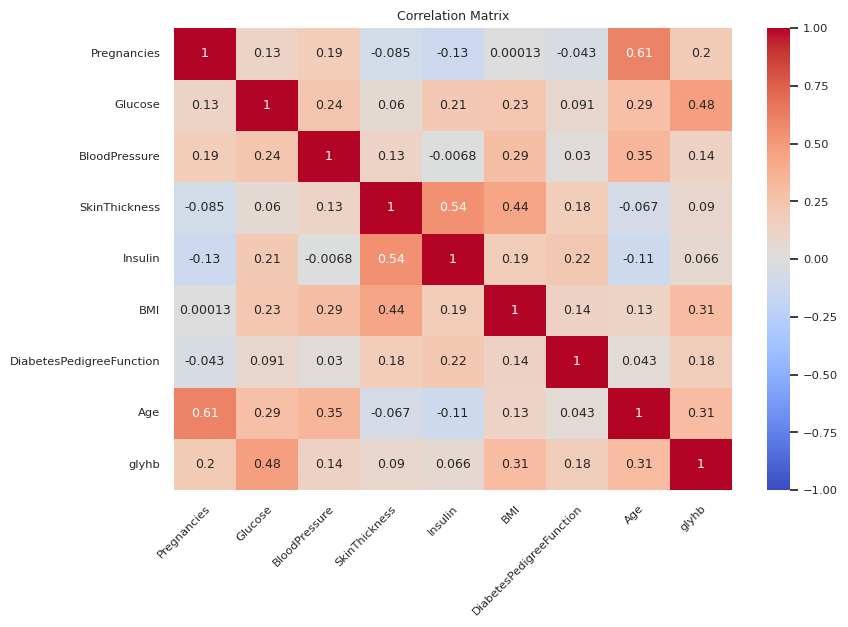

In [75]:
# 9. Exploring the correlation map with glyb for double check
corr = diab_data4_corr.corr('spearman')
plt.figure(figsize=(9,6))
sns.set(font_scale=0.75)
ax = sns.heatmap(corr, vmin=-1, center=0, vmax=1, annot=True, cmap='coolwarm')
# Rotate x-axis labels (column names)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
# Rotate y-axis labels (column names)
plt.setp(ax.get_yticklabels(), rotation=0)
plt.title('Correlation Matrix')
plt.show()

In [76]:
# Comparing correlation of datasets that incaluded in the model 3 and model 4
# Exploring the correlation of features in the Germany data of the model 3
diab_data3.corr(numeric_only=True)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,glyhb
Pregnancies,1.000000,0.120405,0.149672,-0.063375,-0.076600,0.019475,-0.025453,0.539457,-0.009629
Glucose,0.120405,1.000000,0.138044,0.062368,0.320371,0.226864,0.123243,0.254496,0.019731
BloodPressure,0.149672,0.138044,1.000000,0.198800,0.087384,0.281545,0.051331,0.238375,-0.001787
SkinThickness,-0.063375,0.062368,0.198800,1.000000,0.448859,0.393760,0.178299,-0.111034,0.017249
Insulin,-0.076600,0.320371,0.087384,0.448859,1.000000,0.223012,0.192719,-0.085879,0.015345
BMI,0.019475,0.226864,0.281545,0.393760,0.223012,1.000000,0.125719,0.038987,0.029609
DiabetesPedigreeFunction,-0.025453,0.123243,0.051331,0.178299,0.192719,0.125719,1.000000,0.026569,0.012154
Age,0.539457,0.254496,0.238375,-0.111034,-0.085879,0.038987,0.026569,1.000000,-0.007058
glyhb,-0.009629,0.019731,-0.001787,0.017249,0.015345,0.029609,0.012154,-0.007058,1.000000


In [77]:
# Exploring the correlation of the feature in the Db data of the model 4
diab_data4.corr(numeric_only=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,glyhb
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
glyhb,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [78]:
# 10. Building data for the model

# First, ensure consistency by dropping rows with any NaN values from the relevant columns
# This step ensures X and y will have the same number of samples.
diab_data4_cleaned = diab_data4.dropna(how='any')

X = diab_data4_cleaned.drop('glyhb', axis=1)
y = diab_data4_cleaned['glyhb']

# Convert target to binary (1 for diabetes, 0 for no diabetes)
# Using a common clinical threshold for HbA1c: >= 6.5% for diabetes
#y_binary = (y >= 6.5).astype(int)
y_binary = (y > np.median(y)).astype(int)

# Spliting data
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size= 0.3, random_state= 42)

# Normalizing data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

count    768.000000
mean       0.348958
std        0.476951
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: glyhb, dtype: float64


<Axes: xlabel='glyhb', ylabel='Count'>

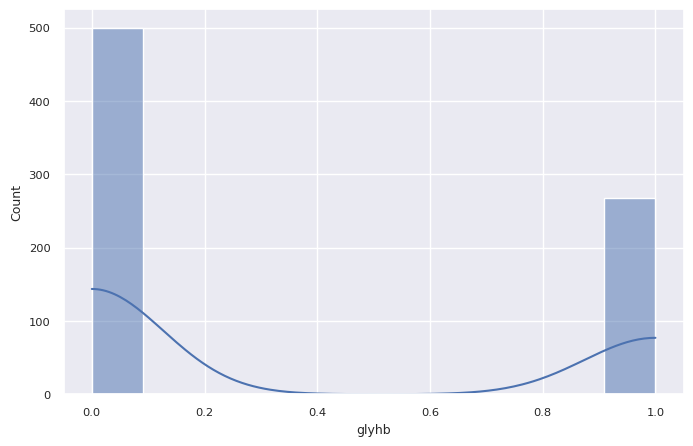

In [79]:
# 11. Exploring the glyhb column
glyb = diab_data4_corr['glyhb']
print(glyb.describe())
plt.figure(figsize=(8, 5))
sns.histplot(glyb.dropna(), kde=True)

In [80]:
# 12. Building the Logistic Regression model
model4 = LogisticRegression()
model4.fit(X_train, y_train)

LogisticRegression()

In [81]:
# 13. Predict on test data
y_pred = model4.predict(X_test)

# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix and Classification Report
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 73.59%
Confusion Matrix:
 [[120  31]
 [ 30  50]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.79      0.80       151
           1       0.62      0.62      0.62        80

    accuracy                           0.74       231
   macro avg       0.71      0.71      0.71       231
weighted avg       0.74      0.74      0.74       231



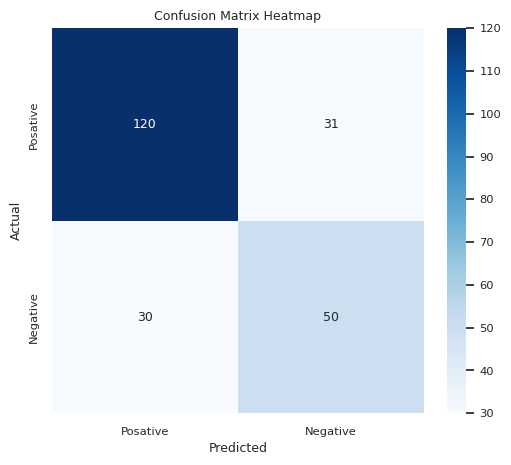

In [82]:
# 14  Plot confusion matrix as heatmap
import seaborn as sns


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Posative', 'Negative'], yticklabels=['Posative', 'Negative'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [83]:
# 15. Printing the resuls (this source for comparing the results with program in the Applied Machine Learning with Python book, page 62)

print('Prediction:', y_pred[1], y_pred[30], y_pred[75])
print('Raw Model Output X_test: ',
      (model4.coef_@ X_test[1]+model4.intercept_),
      (model4.coef_@X_test[10]+model4.intercept_),
      (model4.coef_@X_test[75] + model4.intercept_))

Prediction: 0 1 1
Raw Model Output X_test:  [-1.45766181] [-1.17425557] [0.05258999]


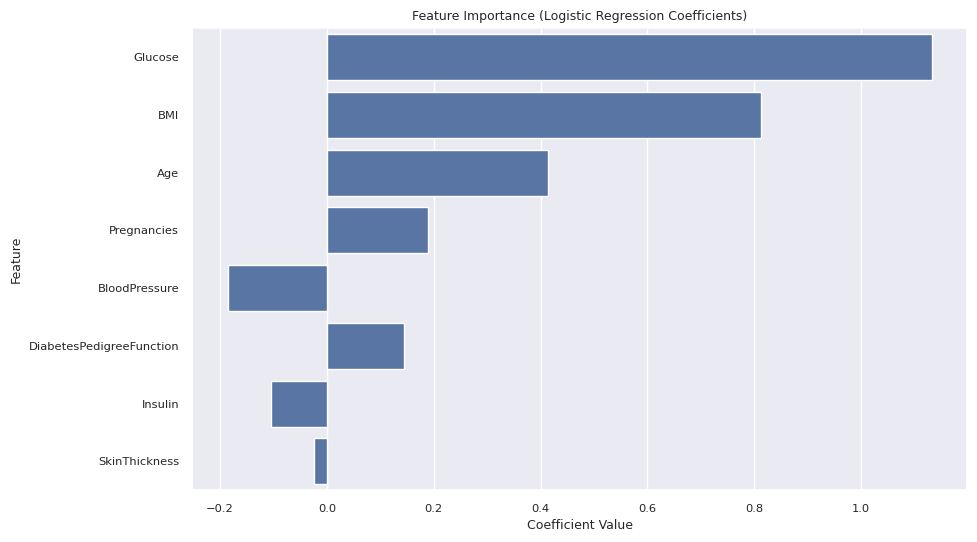

In [84]:
# 16. Coefficients for each feature
feature_importance = pd.DataFrame({'feature': X.columns, 'coefficient': model4.coef_[0]})
feature_importance['abs_coefficient'] = abs(feature_importance['coefficient'])
feature_importance = feature_importance.sort_values(by='abs_coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='coefficient', y='feature', data=feature_importance)
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

AUC Score: 0.7980


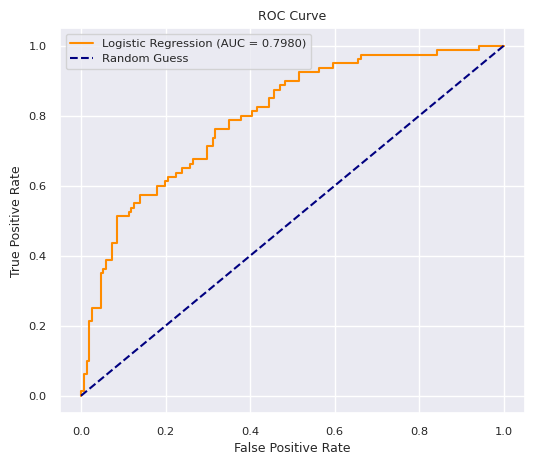

In [85]:
# 17 Plorint area under curve
#Predict probabilities for the positive class
y_probs = model4.predict_proba(X_test)[:, 1]

    # Calculate AUC
from sklearn.metrics import roc_auc_score, roc_curve
auc_score = roc_auc_score(y_test, y_probs)
print(f"AUC Score: {auc_score:.4f}")

# Optional: Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.4f})', color='darkorange',  )
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess', color='navy')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

# 5 Testing Datasets

In [86]:
import seaborn as sns

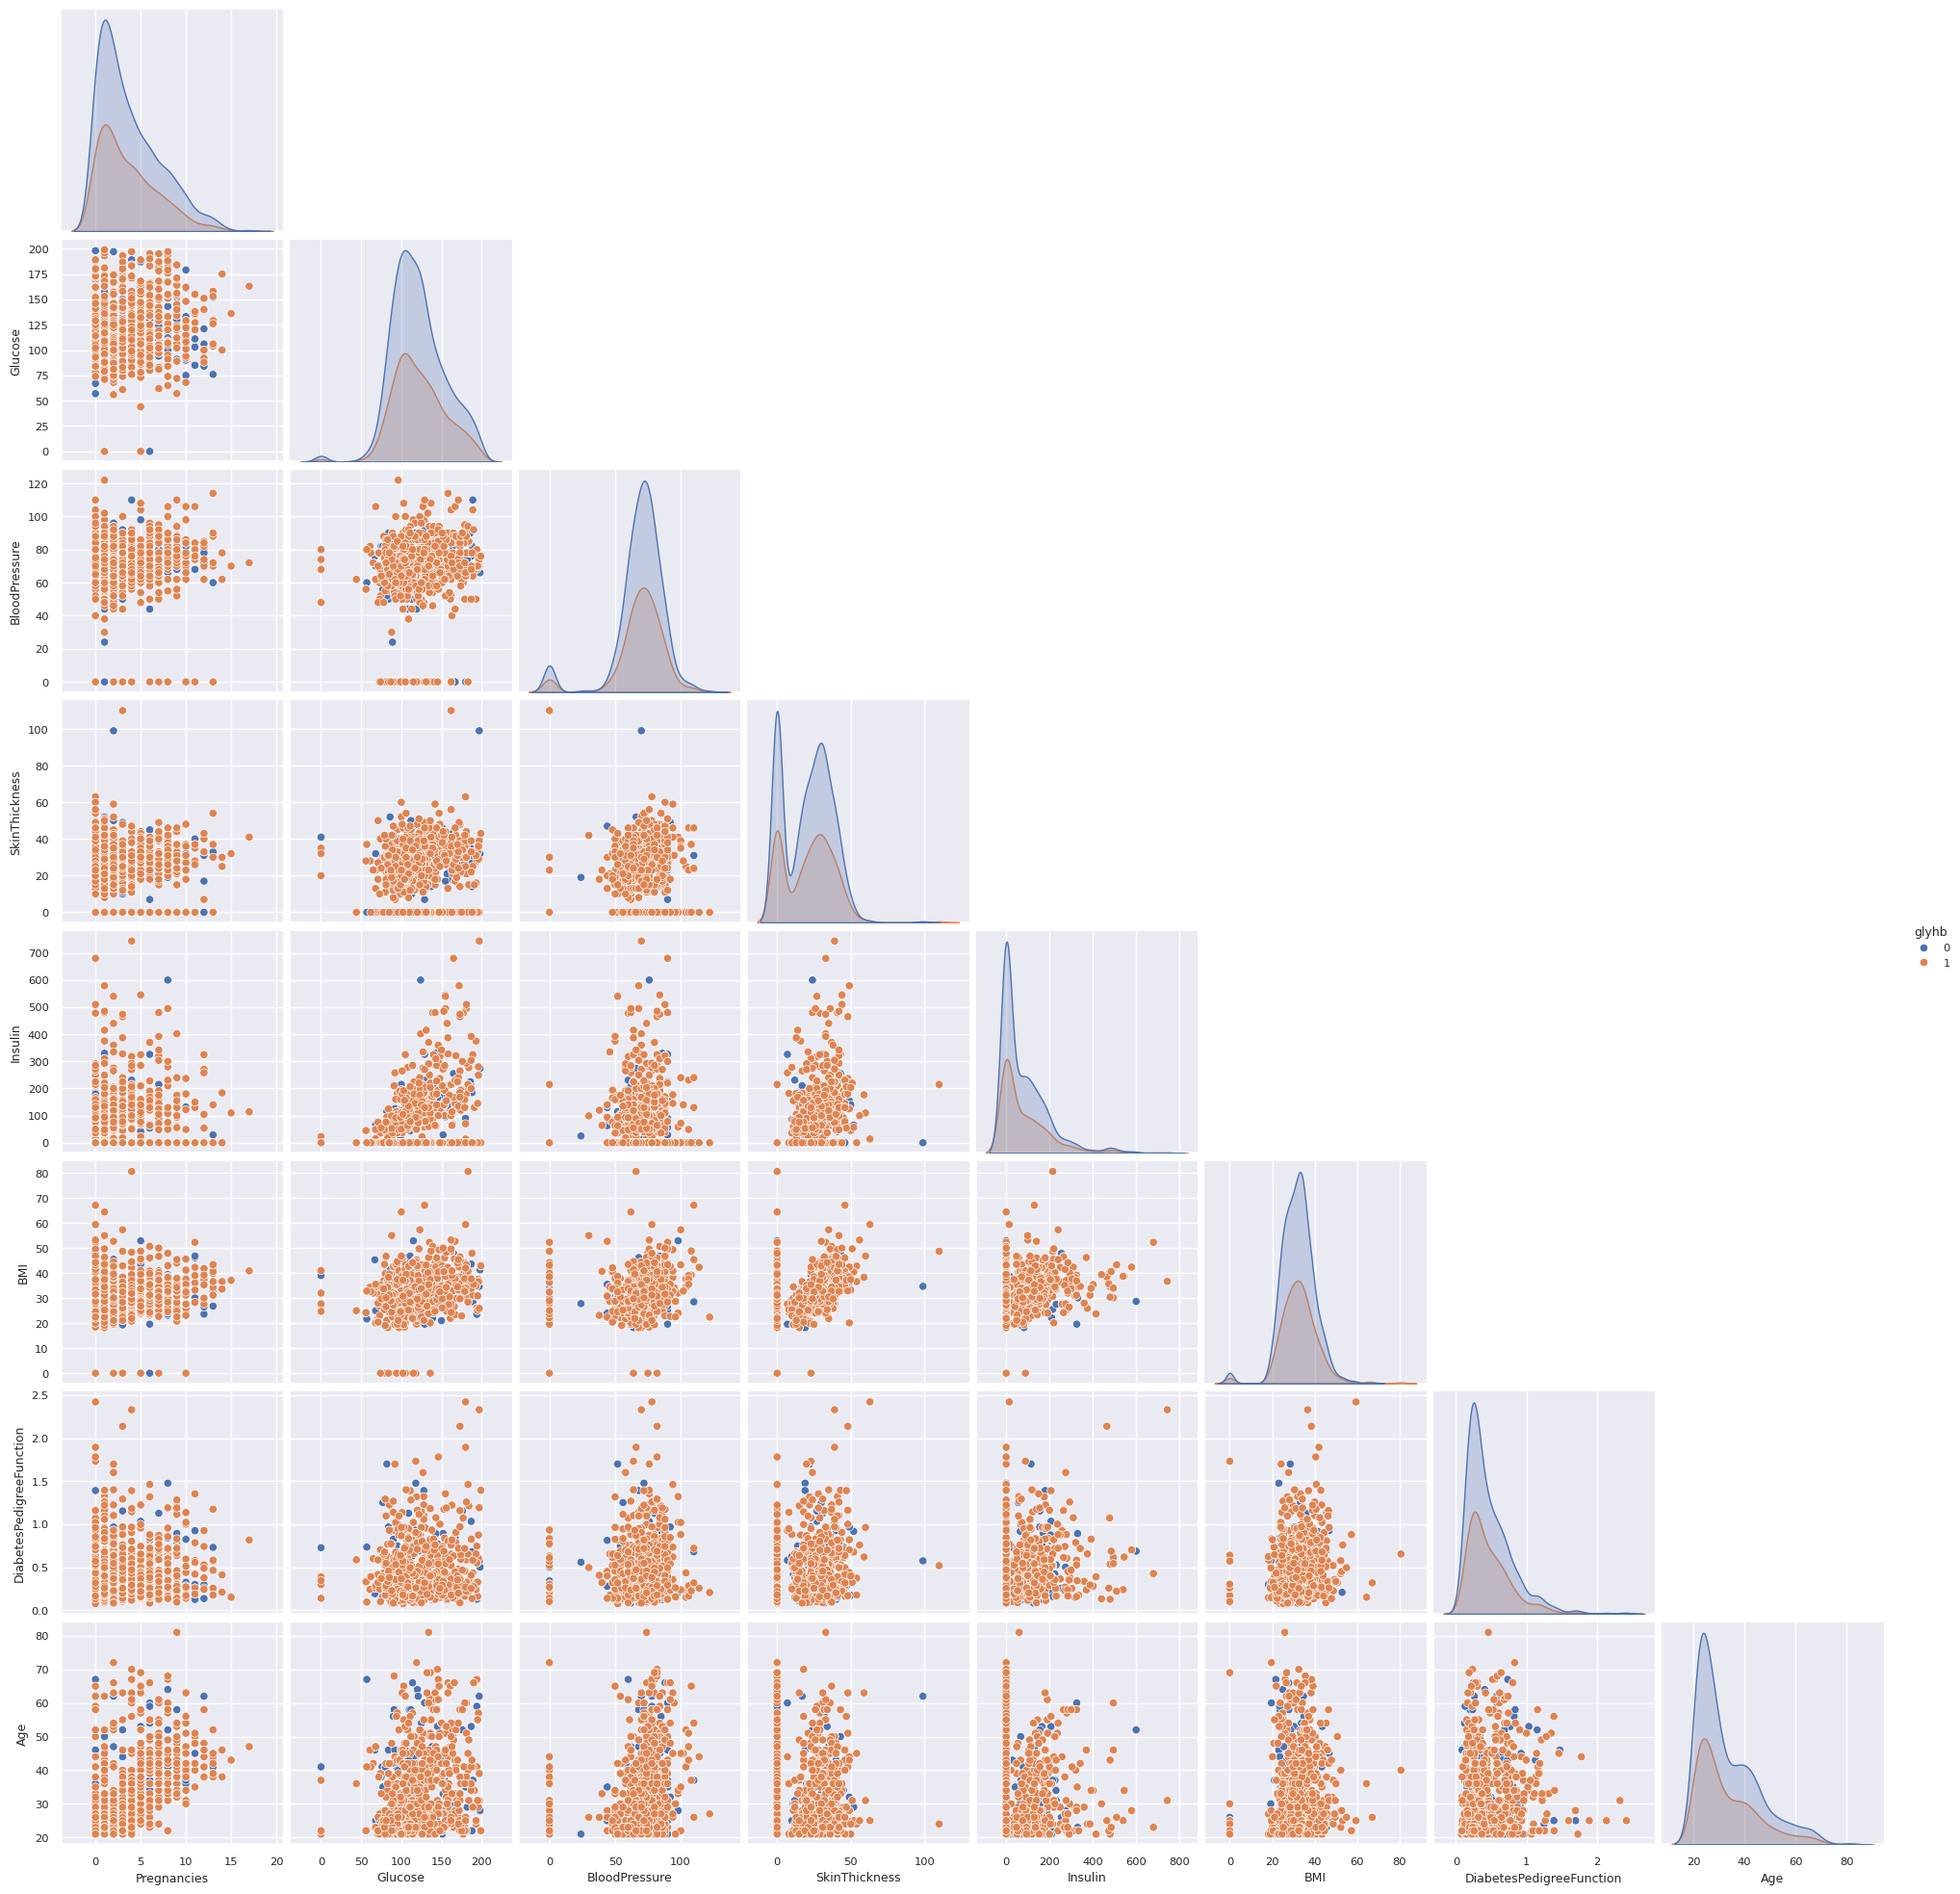

In [102]:
sns.pairplot(diab_data3, hue='glyhb', corner= True);

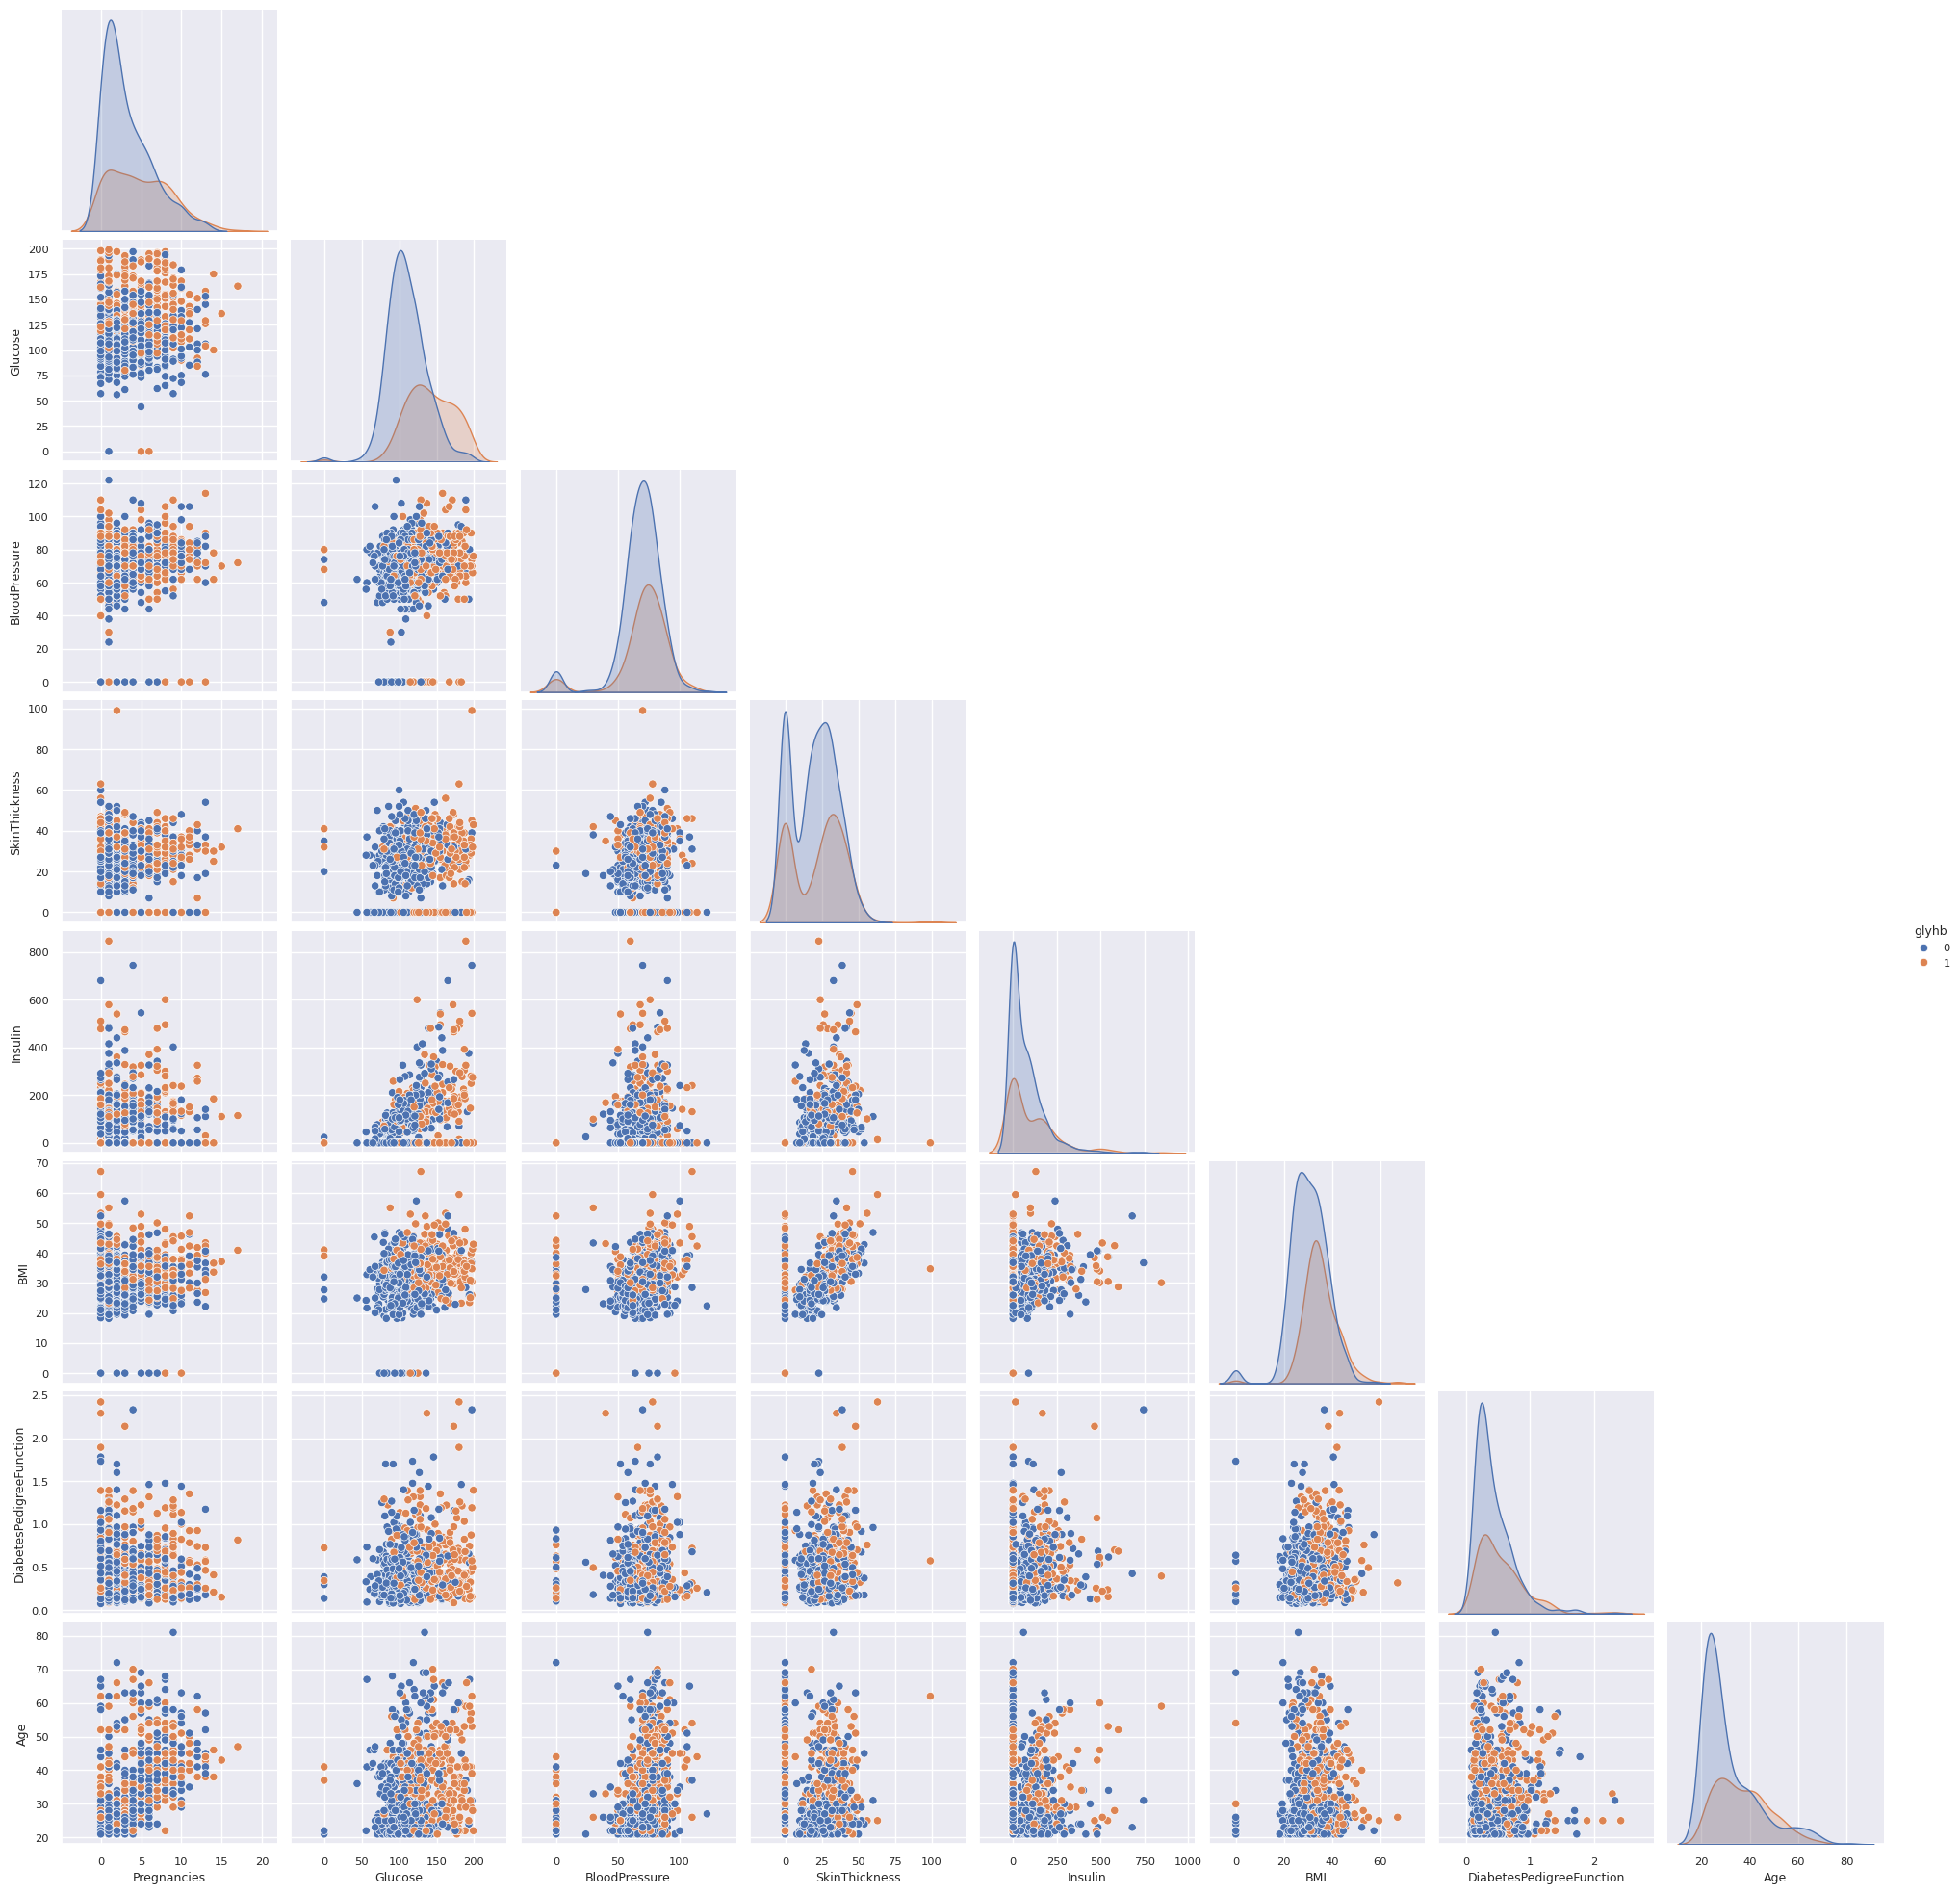

In [103]:
sns.pairplot(diab_data4, hue='glyhb', corner= True);





-------------------------
# This part is for demo test

---



In [89]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
diabetes.target[:3]
diabetes.data.shape

(442, 10)

In [90]:
diabetes.data[:3]

array([[ 0.03807591,  0.05068012,  0.06169621,  0.02187239, -0.0442235 ,
        -0.03482076, -0.04340085, -0.00259226,  0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, -0.02632753, -0.00844872,
        -0.01916334,  0.07441156, -0.03949338, -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, -0.00567042, -0.04559945,
        -0.03419447, -0.03235593, -0.00259226,  0.00286131, -0.02593034]])

# 6 Linear Regression

Mean squared error: 9.54
Coefficient of determination: 0.33


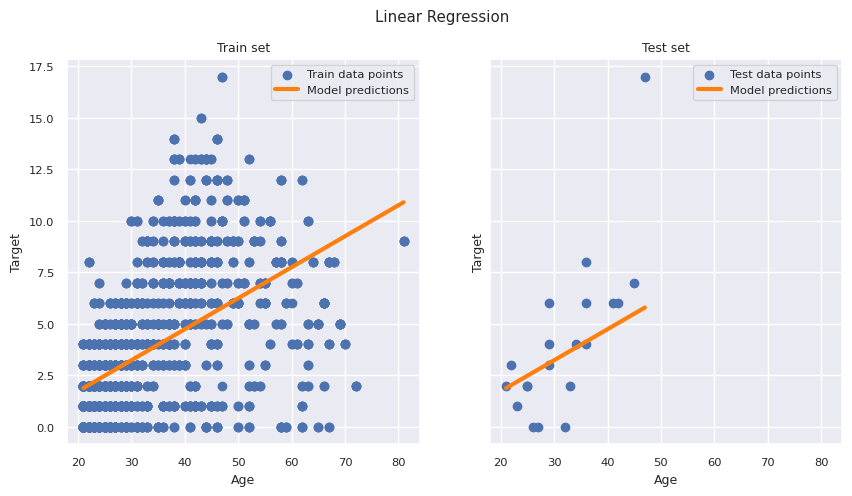

In [91]:
# Using Linear Reagression for testing the corelatino between two selected features in both datasets
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split


'''X, y = load_diabetes(return_X_y=True)
X = X[:, [2]]  # Use only one feature, which is 'bmi' at index 2'''

# Ensure X is a DataFrame with a single column
X = diab_data3[['Age']]
y = diab_data3['Pregnancies']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, shuffle=False)

from sklearn.linear_model import LinearRegression

regressor = LinearRegression().fit(X_train, y_train)

from sklearn.metrics import mean_squared_error, r2_score

y_pred = regressor.predict(X_test)

print(f"Mean squared error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Coefficient of determination: {r2_score(y_test, y_pred):.2f}")

import matplotlib.pyplot as plt
import pandas as pd

fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)

# Choose the correct feature for plotting
feature_name_to_plot = 'Age'

# Training data plot
# Access the single column of the DataFrame using its name
ax[0].scatter(X_train[feature_name_to_plot], y_train, label="Train data points")

# To plot a smooth regression line, sort the feature values and their corresponding predictions
train_data_for_plot = pd.DataFrame({
    feature_name_to_plot: X_train[feature_name_to_plot],
    'prediction': regressor.predict(X_train)
}).sort_values(by=feature_name_to_plot)

ax[0].plot(
    train_data_for_plot[feature_name_to_plot],
    train_data_for_plot['prediction'],
    linewidth=3,
    color="tab:orange",
    label="Model predictions",
)
ax[0].set(xlabel=feature_name_to_plot, ylabel="Target", title="Train set")
ax[0].legend()

# Test data plot
# Access the single column of the DataFrame using its name
ax[1].scatter(X_test[feature_name_to_plot], y_test, label="Test data points")

# To plot a smooth regression line for test data
test_data_for_plot = pd.DataFrame({
    feature_name_to_plot: X_test[feature_name_to_plot],
    'prediction': y_pred
}).sort_values(by=feature_name_to_plot)

ax[1].plot(
    test_data_for_plot[feature_name_to_plot],
    test_data_for_plot['prediction'],
    linewidth=3,
    color="tab:orange",
    label="Model predictions",
)
ax[1].set(xlabel=feature_name_to_plot, ylabel="Target", title="Test set")
ax[1].legend()

fig.suptitle("Linear Regression")

plt.show()

<Axes: >

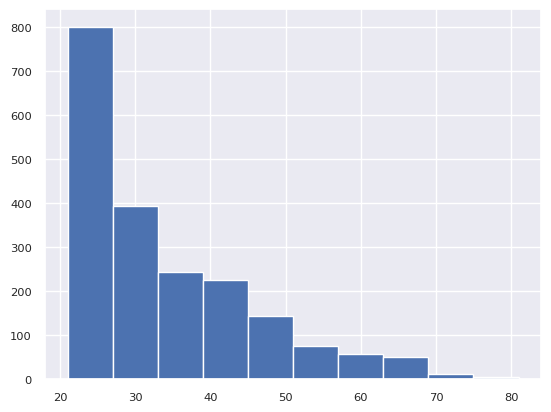

In [92]:
diab_data3['Age'].hist()

<Axes: >

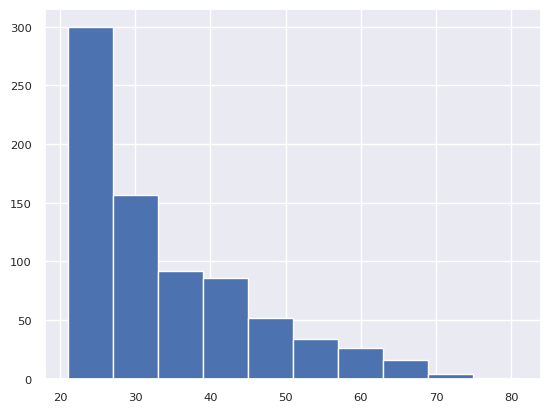

In [93]:
diab_data4['Age'].hist()

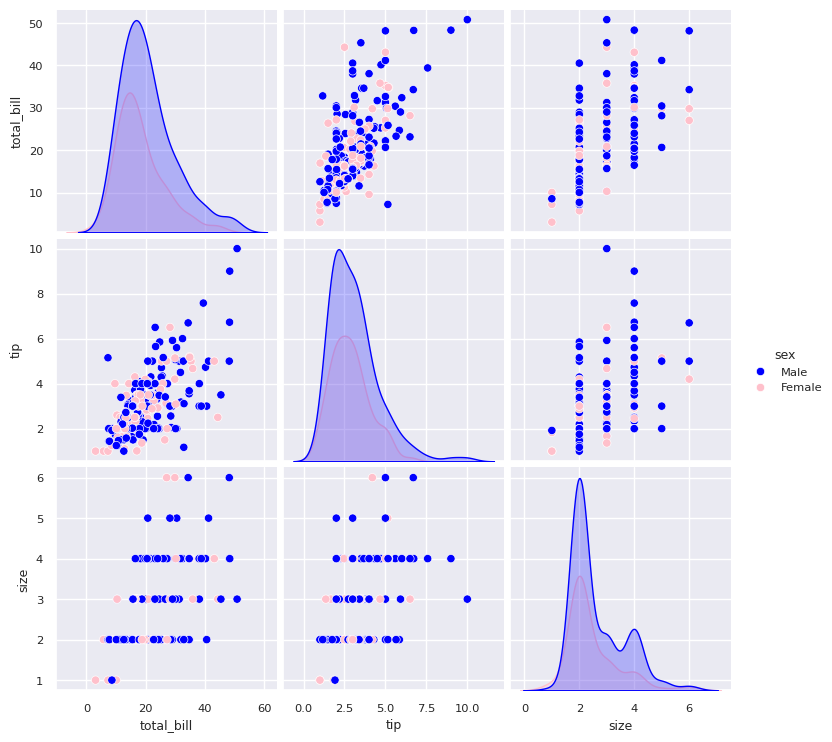

In [94]:
# Load example dataset
tips = sns.load_dataset("tips")
# Create a pairplot with color coding by 'sex'
sns.pairplot(tips, hue="sex", palette={"Male": "blue", "Female": "pink"})
plt.show()

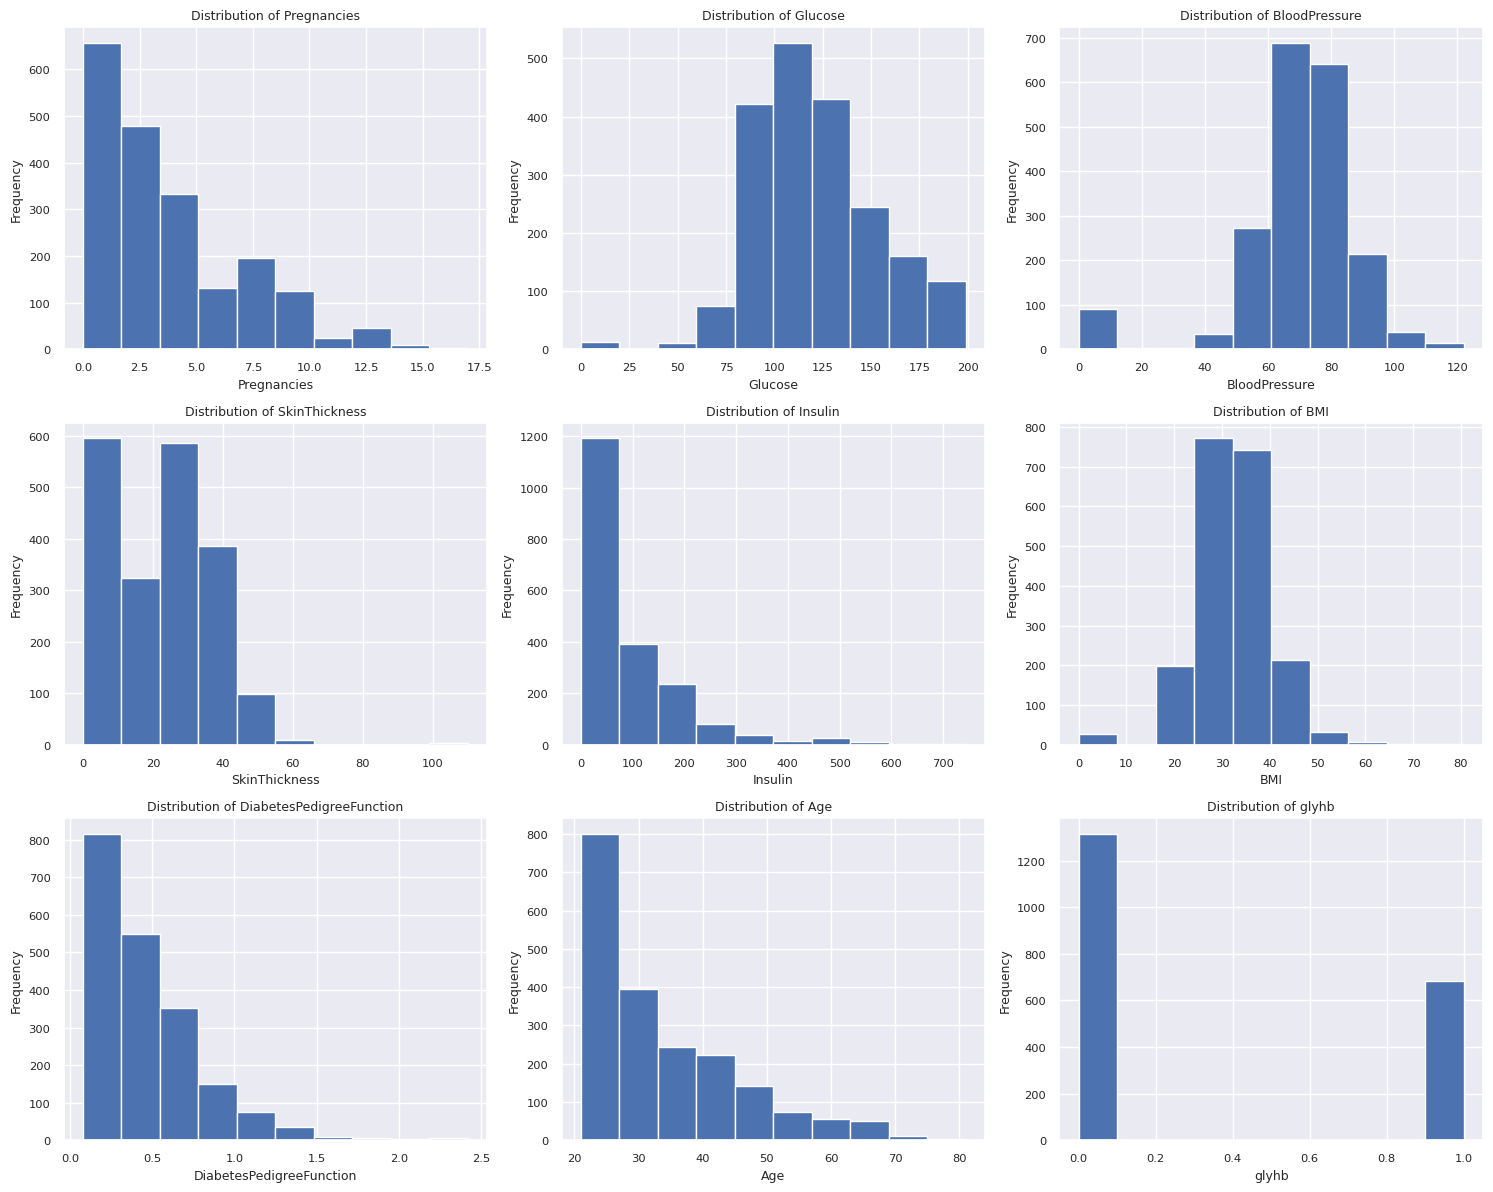

In [95]:
# Create a figure for all histograms
num_data_columns = len(diab_data3.columns)
num_cols_in_grid = 3 # Number of columns for the subplot grid
num_rows_in_grid = (num_data_columns + num_cols_in_grid - 1) // num_cols_in_grid # Calculate required rows

fig, axes = plt.subplots(num_rows_in_grid, num_cols_in_grid, figsize=(num_cols_in_grid * 5, num_rows_in_grid * 4))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, x_col in enumerate(diab_data3.columns):
    if i < len(axes): # Ensure we don't try to plot beyond available subplots
        diab_data3[x_col].plot.hist(ax=axes[i])
        axes[i].set_title(f'Distribution of {x_col}')
        axes[i].set_xlabel(x_col)
        axes[i].set_ylabel('Frequency')

# Hide any unused subplots if the number of data columns is not a perfect multiple of num_cols_in_grid
for j in range(num_data_columns, len(axes)):
    if j < len(axes):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [96]:
diab_data3.rename(columns={'Outcome': 'glyhb'}, inplace=True)

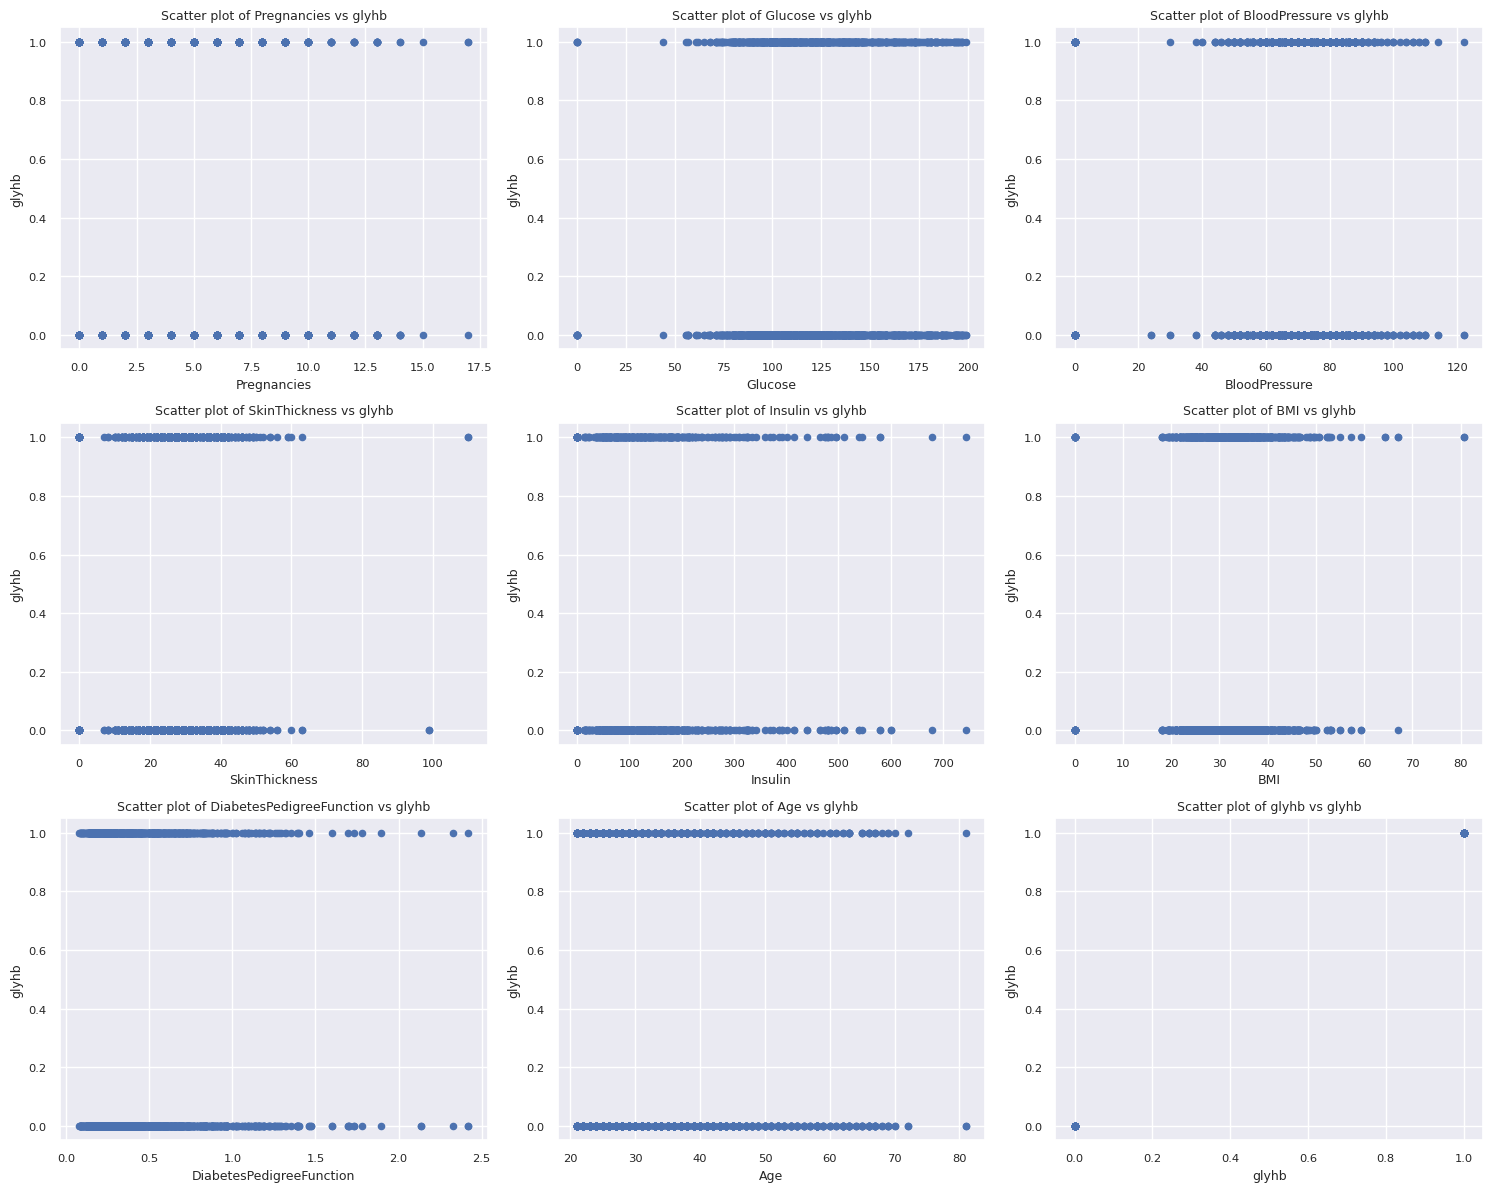

In [97]:
# Create a figure for all scatters
num_data_columns = len(diab_data3.columns)
num_cols_in_grid = 3 # Number of columns for the subplot grid

# Check if diab_data3 is empty or if 'glyhb' column exists
if diab_data3.empty:
    print("diab_data3 is empty after previous operations. Skipping scatter plot generation.")
elif 'glyhb' not in diab_data3.columns:
    print("The 'glyhb' column is not found in diab_data3. Skipping scatter plot generation.")
else:
    num_rows_in_grid = (num_data_columns + num_cols_in_grid - 1) // num_cols_in_grid # Calculate required rows

    fig, axes = plt.subplots(num_rows_in_grid, num_cols_in_grid, figsize=(num_cols_in_grid * 5, num_rows_in_grid * 4))
    axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

    for i, x_col in enumerate(diab_data3.columns):
        if i < len(axes): # Ensure we don't try to plot beyond available subplots
            # Call plot.scatter on the DataFrame itself, specifying x and y column names
            diab_data3.plot.scatter(x=x_col, y='glyhb', ax=axes[i])
            axes[i].set_title(f'Scatter plot of {x_col} vs glyhb')
            axes[i].set_xlabel(x_col)
            axes[i].set_ylabel('glyhb') # Correct ylabel for scatter plot

    # Hide any unused subplots if the number of data columns is not a perfect multiple of num_cols_in_grid
    for j in range(num_data_columns, len(axes)):
        if j < len(axes):
            fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

## 6.1 Comparing the two datasets

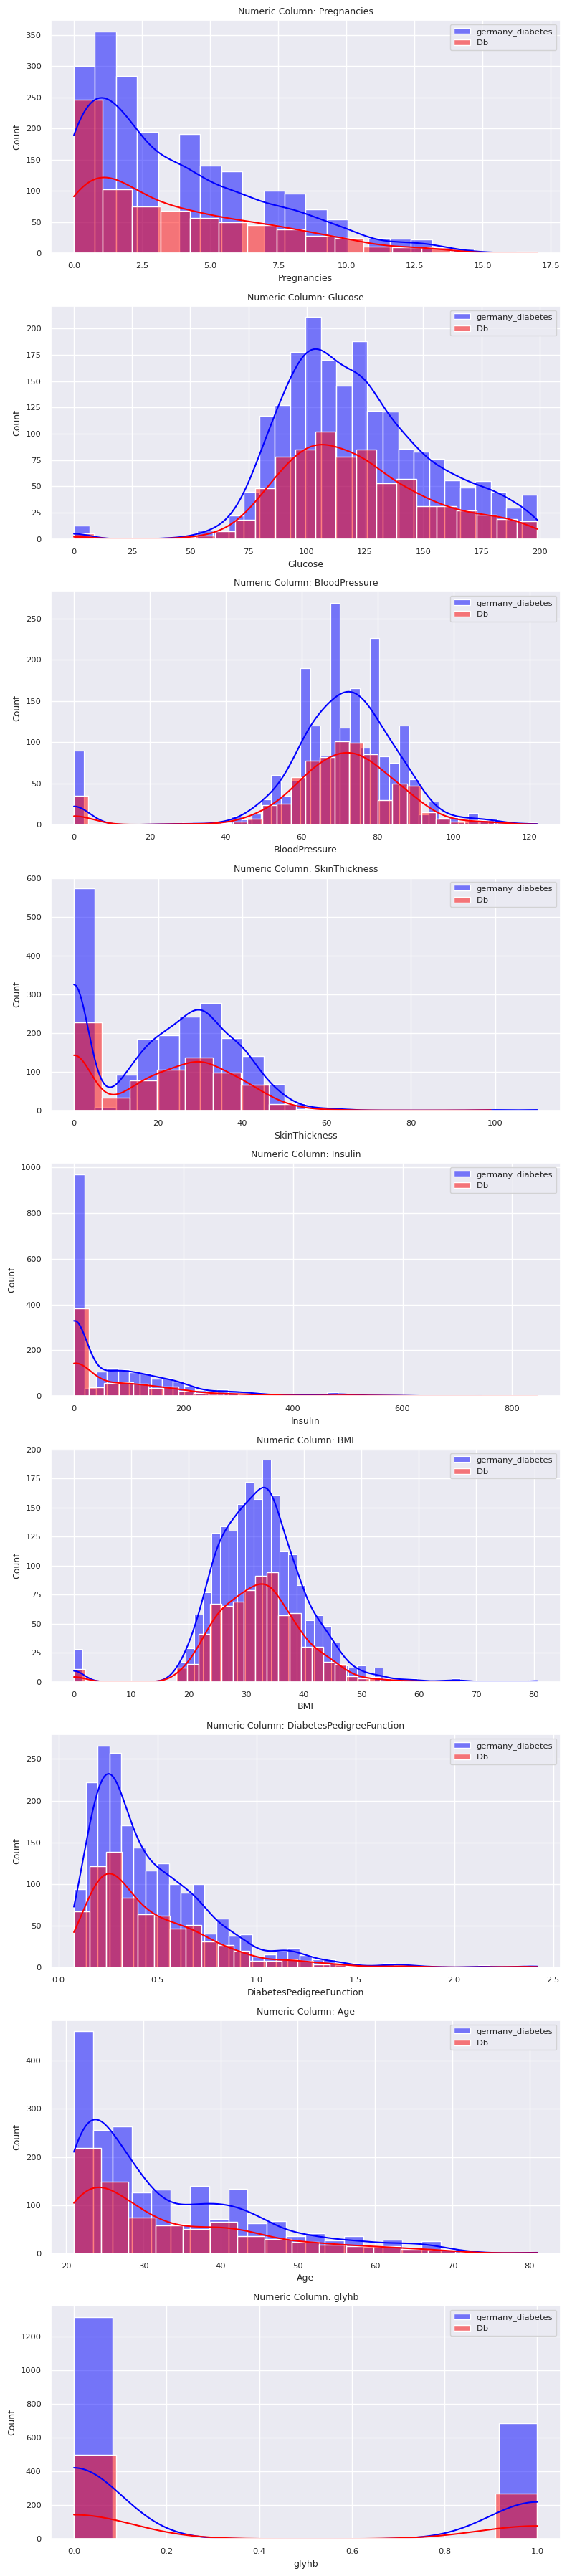

In [98]:
# Comparing germany and db datasets
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



df1 = pd.DataFrame(diab_data3)
df2 = pd.DataFrame(diab_data4)

# Ensure both datasets have the same columns
if set(df1.columns) != set(df2.columns):
    raise ValueError("Datasets must have the same columns for comparison.")

# Create a figure for subplots
num_cols = len(df1.columns)
fig, axes = plt.subplots(num_cols, 1, figsize=(8, 4 * num_cols))

if num_cols == 1:
    axes = [axes]  # Ensure axes is iterable

# Compare each column
for i, col in enumerate(df1.columns):
    if pd.api.types.is_numeric_dtype(df1[col]):
        # Numeric columns: plot side-by-side histograms
        sns.histplot(df1[col], color='blue', label='germany_diabetes', kde=True, ax=axes[i], alpha=0.5)
        sns.histplot(df2[col], color='red', label='Db ', kde=True, ax=axes[i], alpha=0.5)
        axes[i].set_title(f"Numeric Column: {col}")
        axes[i].legend()
    else:
        # Categorical columns: plot count comparison
        df_cat = pd.DataFrame({
            'Dataset': ['germany_diabetes'] * len(df1) + ['Db'] * len(df2),
            col: pd.concat([df1[col], df2[col]], ignore_index=True)
        })
        sns.countplot(data=df_cat, x=col, hue='Dataset', ax=axes[i])
        axes[i].set_title(f"Categorical Column: {col}")

plt.tight_layout()
plt.show()

## 6.2 Linear Regression Model: Predicting Glucose from `diab_data3`

In [99]:
# 1. Using linear regression for comparing Glucose's relations with other features in both datasets
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

# 1. Prepare the data
# Define the target variable (Glucose) and feature variables
y = diab_data3['Glucose']
X = diab_data3.drop('Glucose', axis=1)

# 2. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Feature Scaling
# Standardize features to improve model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames with column names for clarity
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# 4. Train the Linear Regression Model
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

# 5. Evaluate the Model
y_pred = linear_model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Display coefficients (feature importance for linear regression)
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': linear_model.coef_
})
print("\nModel Coefficients:")
display(coefficients.sort_values(by='Coefficient', ascending=False))


Mean Squared Error (MSE): 903.10
R-squared (R2): 0.13

Model Coefficients:


,Feature,Coefficient
3,Insulin,13.180838
6,Age,7.956464
4,BMI,5.877538
1,BloodPressure,1.427927
5,DiabetesPedigreeFunction,1.120099
0,Pregnancies,0.520183
7,glyhb,0.176127
2,SkinThickness,-7.211328


## 6.3 Residual Analysis for `diab_data3`

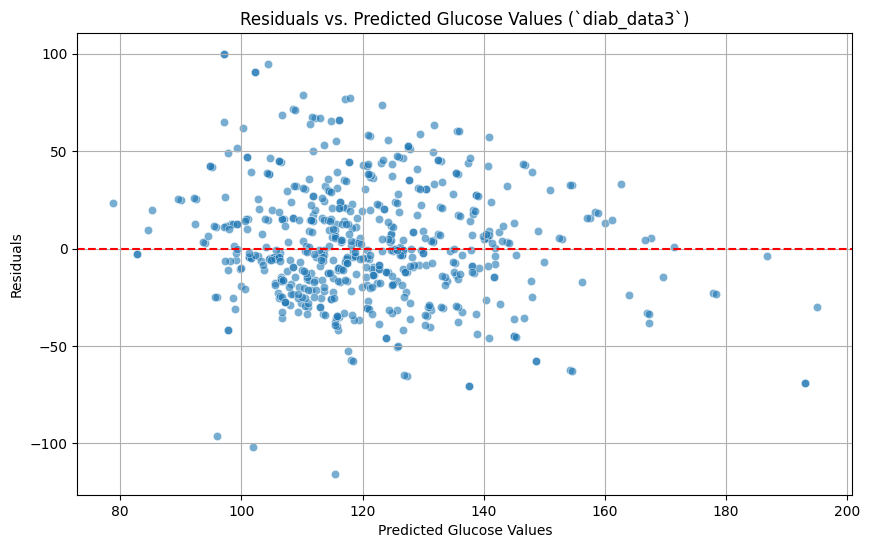

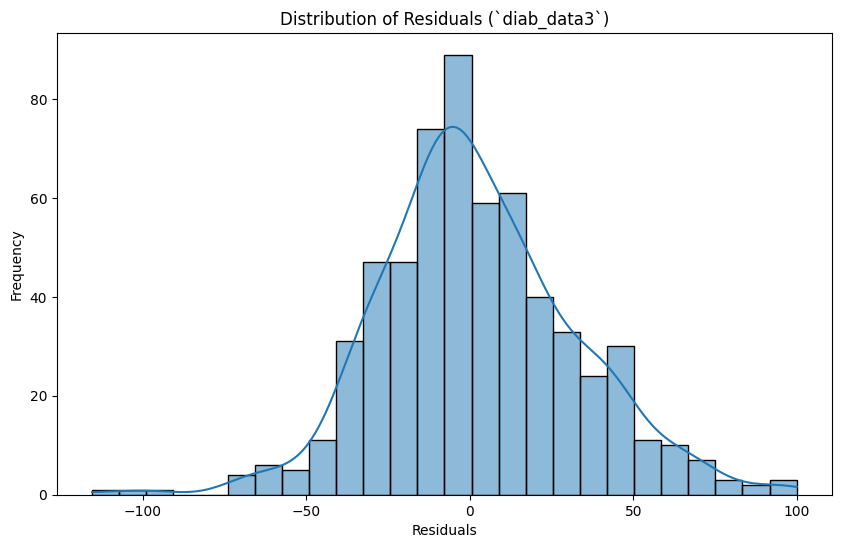

In [3]:


# --- Data Loading and Initial Preprocessing for diab_data3 ---
diab_data3 = pd.read_csv('/content/sample_data/germany_diabetes.csv')
diab_data3 = diab_data3.rename(columns={'Outcome': 'glyhb'})

# --- Re-define y_test and y_pred from the linear regression model for diab_data3 ---
y = diab_data3['Glucose']
X = diab_data3.drop('Glucose', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

y_pred = linear_model.predict(X_test_scaled)

# Calculate residuals
residuals_diab3 = y_test - y_pred

# Plotting residuals vs. predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals_diab3, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Glucose Values (`diab_data3`)')
plt.xlabel('Predicted Glucose Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

# Plotting a histogram of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals_diab3, kde=True)
plt.title('Distribution of Residuals (`diab_data3`)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

In [6]:
# Using linear regression for comparing Glucose's relations with other features in both datasets
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

# 1. Prepare the data
# Define the target variable (Glucose) and feature variables
y = diab_data4['Glucose']
X = diab_data4.drop('Glucose', axis=1)

# 2. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Feature Scaling
# Standardize features to improve model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames with column names for clarity
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# 4. Train the Linear Regression Model
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

# 5. Evaluate the Model
y_pred = linear_model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Display coefficients (feature importance for linear regression)
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': linear_model.coef_
})
print("\nModel Coefficients:")
display(coefficients.sort_values(by='Coefficient', ascending=False))


NameError: name 'diab_data4' is not defined

## 6.4 Residual Analysis for `diab_data4`

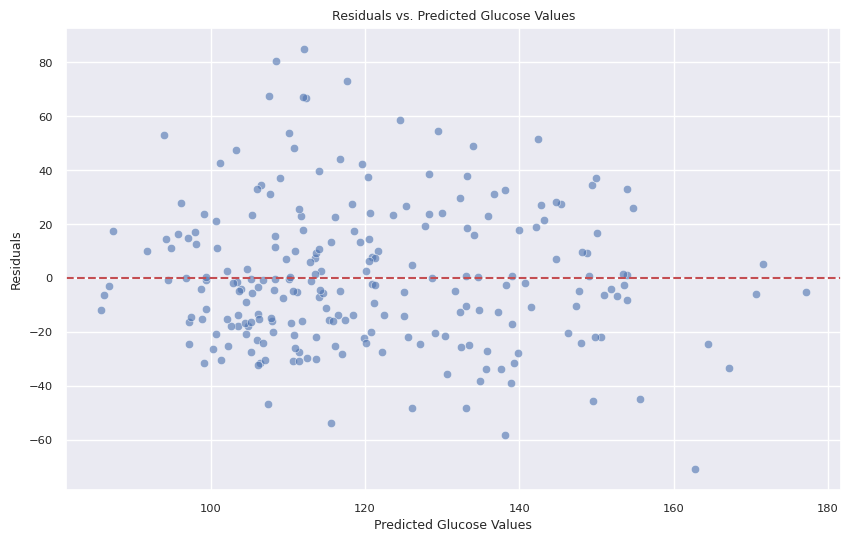

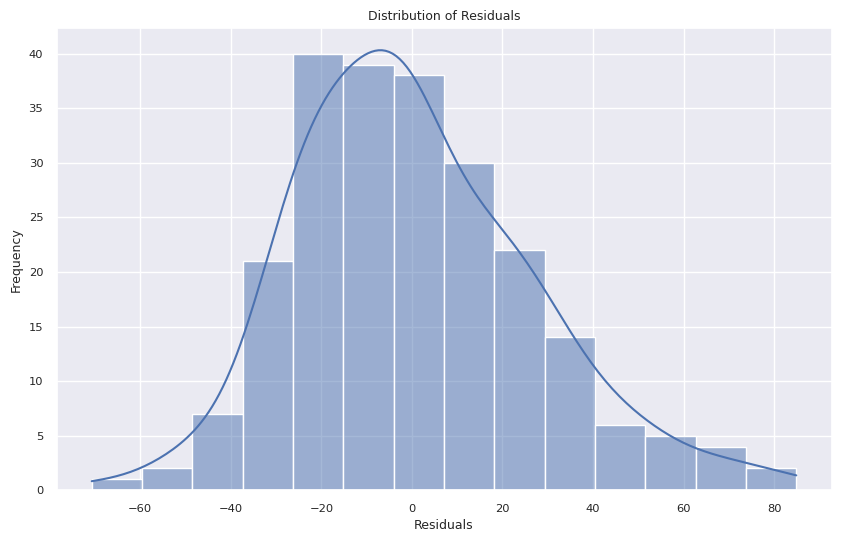

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals = y_test - y_pred

# Plotting residuals vs. predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Glucose Values')
plt.xlabel('Predicted Glucose Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

# Plotting a histogram of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()